<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/51_python_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SBA Loan Default -Shruti Rajput 51


##Data Loading and Initial Inspection

In [113]:
import pandas as pd

df = pd.read_csv('/content/Sba loan.csv')
display(df.head())

,BankState,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
0,CA,2001,36,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0,0.5,0
1,CA,2001,56,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0,0.5,1
2,CA,2001,36,10,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0,0.5,0
3,CA,2003,36,6,1.0,0,0,0,Y,N,P I F,0,50000,25000,0,0,0.5,0
4,CO,2006,240,65,1.0,3,65,1,0,N,P I F,0,343000,343000,0,1,1.0,0


In [114]:
df.tail()

,BankState,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
2097,CA,2006,60,5,2.0,0,5,1,0,N,P I F,0,150000,75000,1,0,0.50,0
2098,UT,1997,300,4,1.0,0,0,0,0,N,P I F,0,99000,79200,0,1,0.80,0
2099,CA,1997,84,2,1.0,0,0,0,0,N,P I F,0,50000,40000,0,0,0.80,0
2100,CA,1997,120,3,1.0,0,0,0,0,N,P I F,0,500000,375000,0,0,0.75,0
2101,SD,1997,60,4,1.0,0,0,0,T,N,P I F,0,35000,17500,0,0,0.50,0


In [115]:
df.shape

(2102, 18)

In [116]:
df.describe()

,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
count,2102.000000,2102.000000,2102.000000,2101.000000,2102.000000,2102.000000,2102.000000,2.102000e+03,2.102000e+03,2.102000e+03,2102.000000,2102.000000,2102.000000,2102.000000
mean,2004.035680,126.980495,10.150809,1.153736,2.549952,5.803996,0.949572,2.002908e+04,2.330641e+05,1.891759e+05,0.154139,0.274500,0.671055,0.068506
std,4.006321,93.798944,34.402420,0.362099,8.010175,18.977996,0.410856,7.543229e+04,3.436310e+05,2.989268e+05,0.361168,0.446368,0.186519,0.252673
min,1989.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,4.500000e+03,2.250000e+03,0.000000,0.000000,0.296770,0.000000
25%,2003.000000,60.000000,2.000000,1.000000,0.000000,1.000000,1.000000,0.000000e+00,3.000000e+04,1.500000e+04,0.000000,0.000000,0.500000,0.000000
50%,2005.000000,84.000000,3.000000,1.000000,0.000000,2.000000,1.000000,0.000000e+00,6.100000e+04,4.168000e+04,0.000000,0.000000,0.500000,0.000000
75%,2007.000000,240.000000,8.000000,1.000000,2.000000,5.000000,1.000000,1.507350e+04,3.000000e+05,2.397562e+05,0.000000,1.000000,0.850000,0.000000
max,2012.000000,306.000000,650.000000,2.000000,130.000000,535.000000,2.000000,1.509550e+06,2.350000e+06,2.115000e+06,1.000000,1.000000,1.000000,1.000000


## **Data Cleaning**

In [117]:
print(df.isnull().sum())

BankState       3
ApprovalFY      0
Term            0
NoEmp           0
NewExist        1
CreateJob       0
RetainedJob     0
UrbanRural      0
RevLineCr       2
LowDoc          3
MIS_Status      0
ChgOffPrinGr    0
GrAppv          0
SBA_Appv        0
New             0
RealEstate      0
Portion         0
Recession       0
dtype: int64


We have null values in Newexist ,revlinecr and Lowdoc . we will remove them directly.

In [118]:
df.dropna(subset=['NewExist', 'RevLineCr', 'LowDoc'], inplace=True)
print(df.isnull().sum())

BankState       3
ApprovalFY      0
Term            0
NoEmp           0
NewExist        0
CreateJob       0
RetainedJob     0
UrbanRural      0
RevLineCr       0
LowDoc          0
MIS_Status      0
ChgOffPrinGr    0
GrAppv          0
SBA_Appv        0
New             0
RealEstate      0
Portion         0
Recession       0
dtype: int64


Null values treated

In [119]:
df = df.drop(columns=['BankState', 'ApprovalFY','New'])
display(df.head())

,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,RealEstate,Portion,Recession
0,36,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0.5,0
1,56,1,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0.5,1
2,36,10,1.0,0,0,0,Y,N,P I F,0,30000,15000,0,0.5,0
3,36,6,1.0,0,0,0,Y,N,P I F,0,50000,25000,0,0.5,0
4,240,65,1.0,3,65,1,0,N,P I F,0,343000,343000,1,1.0,0


Dropping Bank State , ApprovalFy ,New because they are irrelevant

In [120]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 95


Checking for Duplicates , we will remove them

In [121]:
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows after removal: 0


## **Outlier Detection**

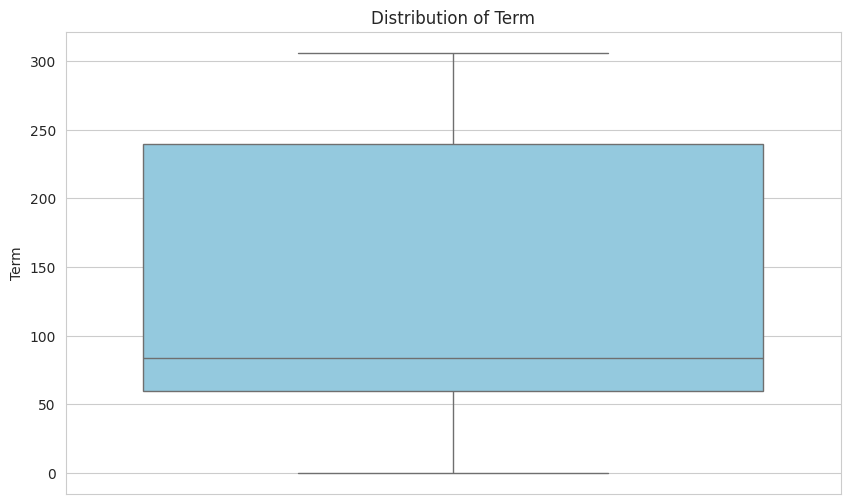

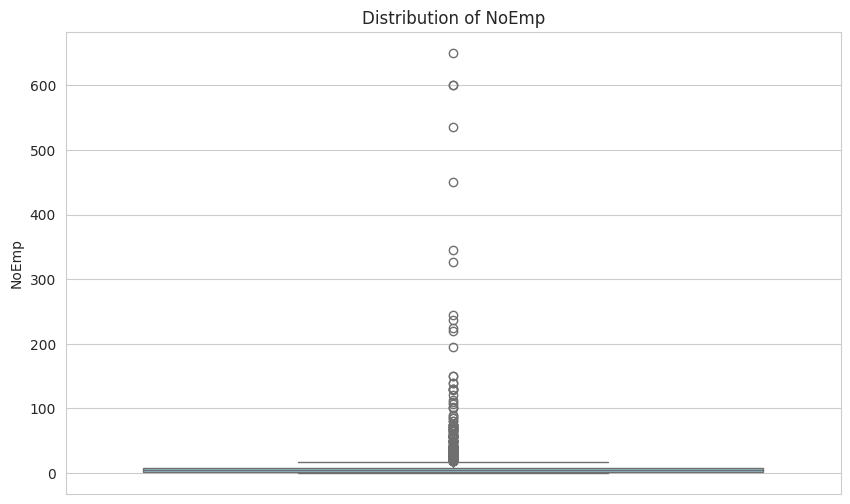

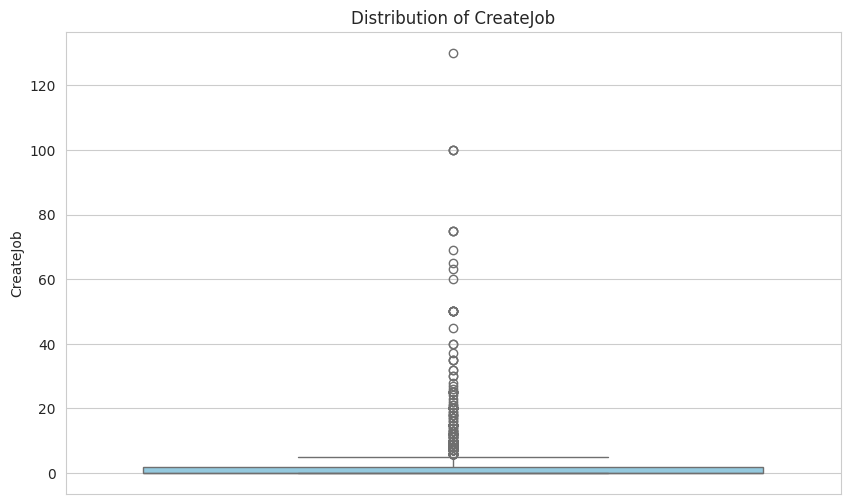

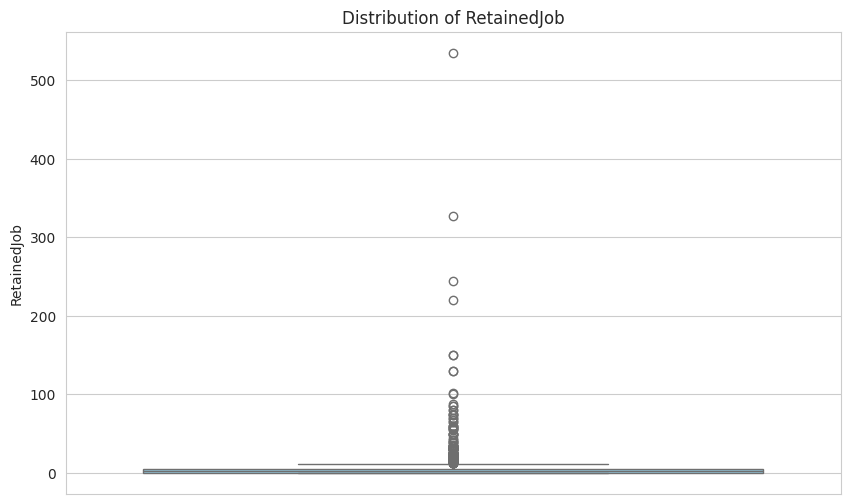

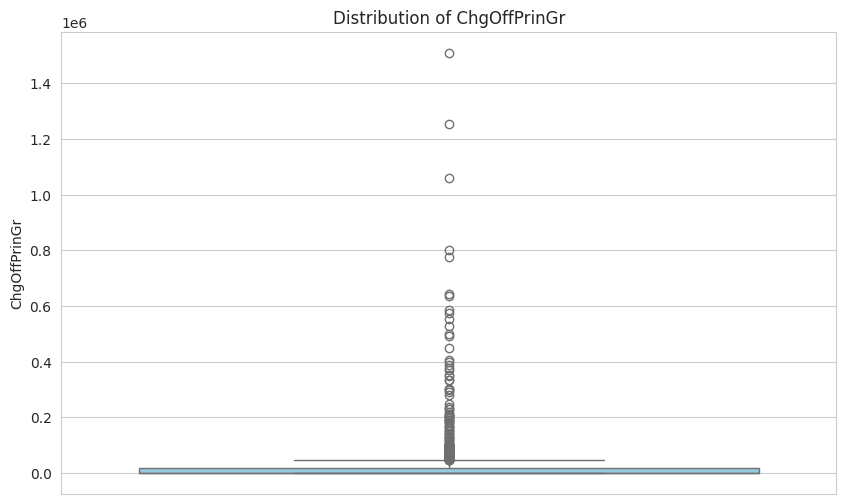

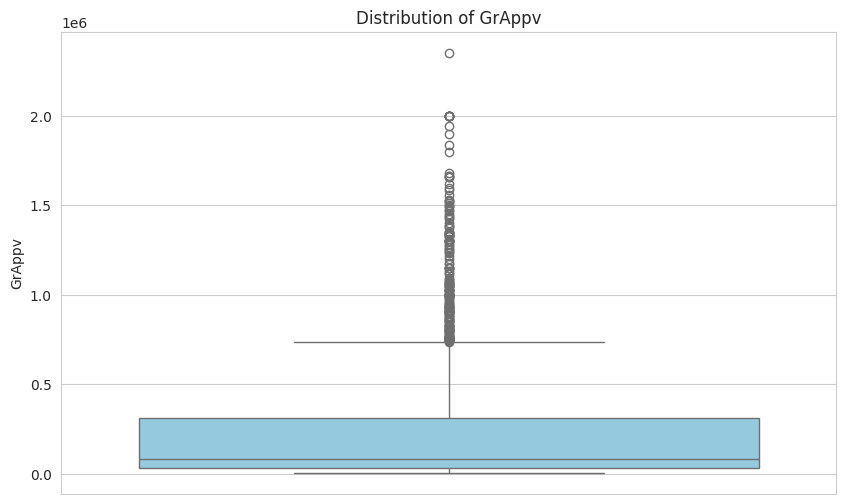

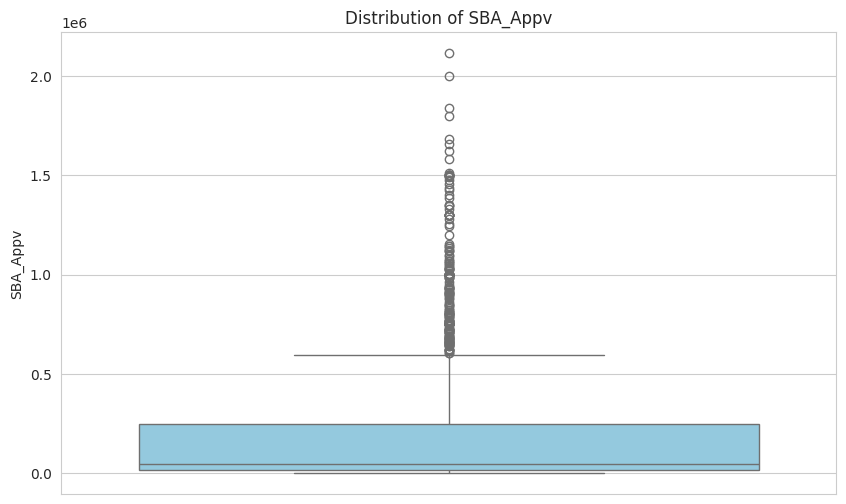

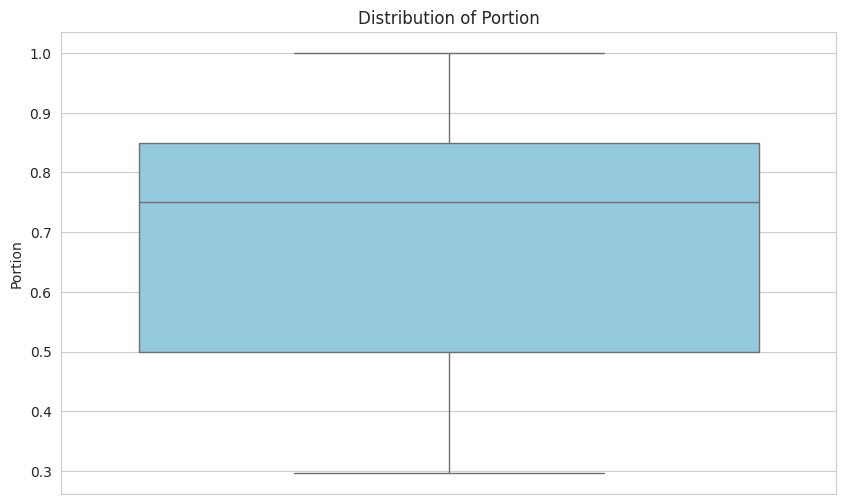

All relevant numerical box plots generated.


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# Get numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Define columns that are conceptually categorical/binary but are of numerical type
# and thus not suitable for typical outlier detection via box plots
excluded_cols = [
    'MIS_Status',
    'NewExist',
    'UrbanRural',
    'RevLineCr',
    'LowDoc',
    'New',
    'RealEstate',
    'Recession'
]

# Filter out the excluded columns to get only continuous numerical features
numerical_cols_for_outliers = [col for col in numerical_cols if col not in excluded_cols]

if not numerical_cols_for_outliers:
    print("No continuous numerical columns found for outlier detection after filtering.")
else:
    for col in numerical_cols_for_outliers:
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=col, data=df, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.ylabel(col)
        plt.show()

    print("All relevant numerical box plots generated.")

In [123]:
# Identify numerical columns for outlier treatment (excluding binary/categorical ones)
numerical_cols_for_outliers = [
    'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv', 'Portion'
]

# Function to cap outliers using IQR method
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply outlier capping to the selected numerical columns
for col in numerical_cols_for_outliers:
    df = cap_outliers_iqr(df.copy(), col)

print("Outliers in specified numerical columns have been capped using the IQR method.")

# Display descriptive statistics after outlier treatment to see the effect
display(df[numerical_cols_for_outliers].describe())

Outliers in specified numerical columns have been capped using the IQR method.


,Term,NoEmp,CreateJob,RetainedJob,ChgOffPrinGr,GrAppv,SBA_Appv,Portion
count,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000,2001.000000
mean,129.063968,5.830085,1.289855,3.651674,10546.750125,205565.646677,162379.679160,0.678789
std,95.532695,5.303972,1.823991,4.071407,17157.667832,242366.590648,203076.331794,0.187041
min,0.000000,0.000000,0.000000,0.000000,0.000000,4500.000000,2250.000000,0.296770
25%,60.000000,2.000000,0.000000,0.000000,0.000000,30000.000000,17000.000000,0.500000
50%,84.000000,4.000000,0.000000,2.000000,0.000000,80000.000000,50000.000000,0.750000
75%,240.000000,8.000000,2.000000,5.000000,19119.000000,312000.000000,251250.000000,0.850000
max,306.000000,17.000000,5.000000,12.500000,47797.500000,735000.000000,602625.000000,1.000000


Standard scaling and normalization

In [124]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identify numerical columns to scale from the final model's features (excluding categorical/binary ones)
numerical_cols_to_scale = ['Term', 'NoEmp']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the training data's numerical columns
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Transform both training and testing data's numerical columns
X_test_scaled_numerical = scaler.transform(X_test[numerical_cols_to_scale])

# Convert scaled arrays back to DataFrame and preserve column names and index
X_train_scaled_numerical = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols_to_scale, index=X_train.index)
X_test_scaled_numerical = pd.DataFrame(X_test_scaled_numerical, columns=numerical_cols_to_scale, index=X_test.index)

# Drop original numerical columns from X_train and X_test
X_train_no_numerical = X_train.drop(columns=numerical_cols_to_scale)
X_test_no_numerical = X_test.drop(columns=numerical_cols_to_scale)

# Concatenate scaled numerical columns back with the rest of the features
X_train_scaled = pd.concat([X_train_scaled_numerical, X_train_no_numerical], axis=1)
X_test_scaled = pd.concat([X_test_scaled_numerical, X_test_no_numerical], axis=1)

print("Numerical features scaled successfully.")

# Display the head of the scaled training data
display(X_train_scaled.head())
# Display the head of the scaled testing data
display(X_test_scaled.head())

Numerical features scaled successfully.


,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,SBA_Appv,RealEstate,Portion,Recession
294,-0.391792,-0.255169,1.0,1,1,1,0,0,106250,0,0.85,0
728,-0.519096,-0.225582,1.0,0,3,1,1,0,25000,0,0.50,0
1956,1.199503,1.165019,1.0,20,0,2,0,0,833000,1,1.00,0
2066,-0.455444,-0.284756,2.0,0,1,1,0,0,12750,0,0.85,0
1019,-0.073533,0.395750,1.0,24,24,1,0,0,842400,0,0.90,0


,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,SBA_Appv,RealEstate,Portion,Recession
1283,1.836021,-0.255169,1.0,0,2,1,0,0,283125,1,0.75,0
1759,-1.335960,-0.136820,1.0,0,6,2,0,0,12500,0,0.50,0
1963,-0.455444,-0.136820,1.0,0,6,1,1,0,17500,0,0.50,0
1075,1.836021,-0.048058,1.0,0,9,1,0,0,506250,1,0.75,0
2100,-0.073533,-0.225582,1.0,0,0,0,0,0,375000,0,0.75,0


## Label Encoding


we have Categorical features like RevLineCr, LowDoc, and MIS_Status(target Variable ) converting them  into numerical representations (0s and 1s) for model compatibility.

In [125]:
# Reload the original DataFrame to undo the corrupted state
df = pd.read_csv('/content/Sba loan.csv')

# Re-apply previous cleaning steps
df = df.drop(columns=['BankState', 'ApprovalFY'])
df.dropna(subset=['NewExist', 'RevLineCr', 'LowDoc'], inplace=True)
df.drop_duplicates(inplace=True)

print('Original unique values for categorical columns after reload and clean:')
print(f"RevLineCr: {df['RevLineCr'].unique()}")
print(f"LowDoc: {df['LowDoc'].unique()}")
print(f"MIS_Status: {df['MIS_Status'].unique()}")

# Correctly map categorical values to numerical representations
df['RevLineCr'] = df['RevLineCr'].map({'0': 0, 'N': 0, 'T': 1, 'Y': 1})
df['LowDoc'] = df['LowDoc'].map({'N': 0, 'S': 0, 'A': 0, '0': 0, 'Y': 1})
df['MIS_Status'] = df['MIS_Status'].map({'P I F': 0, 'CHGOFF': 1})

print('\nEncoded unique values for categorical columns after corrected mapping:')
print(f"RevLineCr: {df['RevLineCr'].unique()}")
print(f"LowDoc: {df['LowDoc'].unique()}")
print(f"MIS_Status: {df['MIS_Status'].unique()}")

display(df.head())

Original unique values for categorical columns after reload and clean:
RevLineCr: ['Y' '0' 'N' 'T']
LowDoc: ['N' 'Y' 'S' 'A' '0']
MIS_Status: ['P I F' 'CHGOFF']

Encoded unique values for categorical columns after corrected mapping:
RevLineCr: [1 0]
LowDoc: [0 1]
MIS_Status: [0 1]


,Term,NoEmp,NewExist,CreateJob,RetainedJob,UrbanRural,RevLineCr,LowDoc,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,New,RealEstate,Portion,Recession
0,36,1,1.0,0,0,0,1,0,0,0,30000,15000,0,0,0.5,0
1,56,1,1.0,0,0,0,1,0,0,0,30000,15000,0,0,0.5,1
2,36,10,1.0,0,0,0,1,0,0,0,30000,15000,0,0,0.5,0
3,36,6,1.0,0,0,0,1,0,0,0,50000,25000,0,0,0.5,0
4,240,65,1.0,3,65,1,0,0,0,0,343000,343000,0,1,1.0,0


Now all the columns are succesfully encoded


## Univariate Analysis

Generating plots for continuous numerical columns...


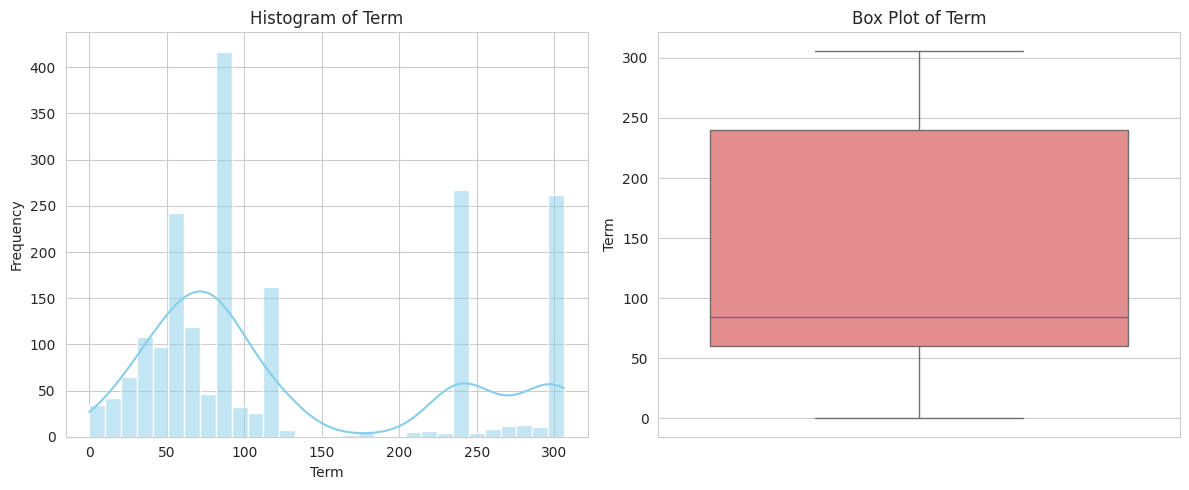

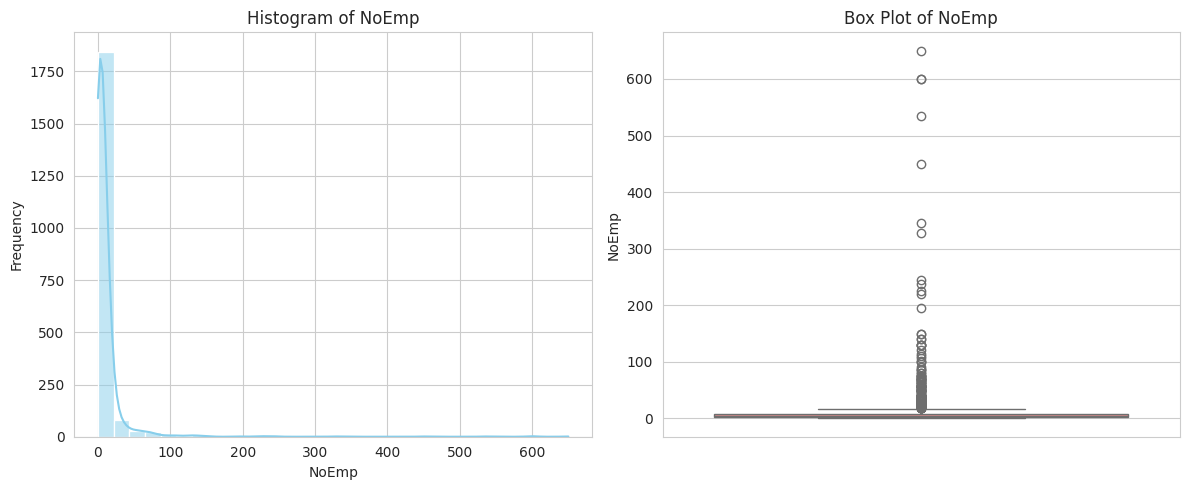

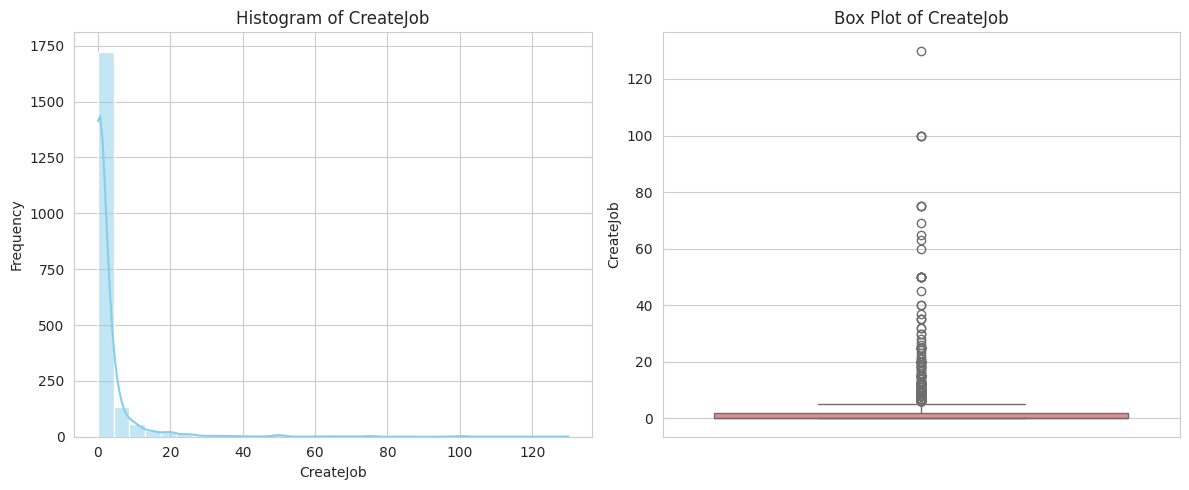

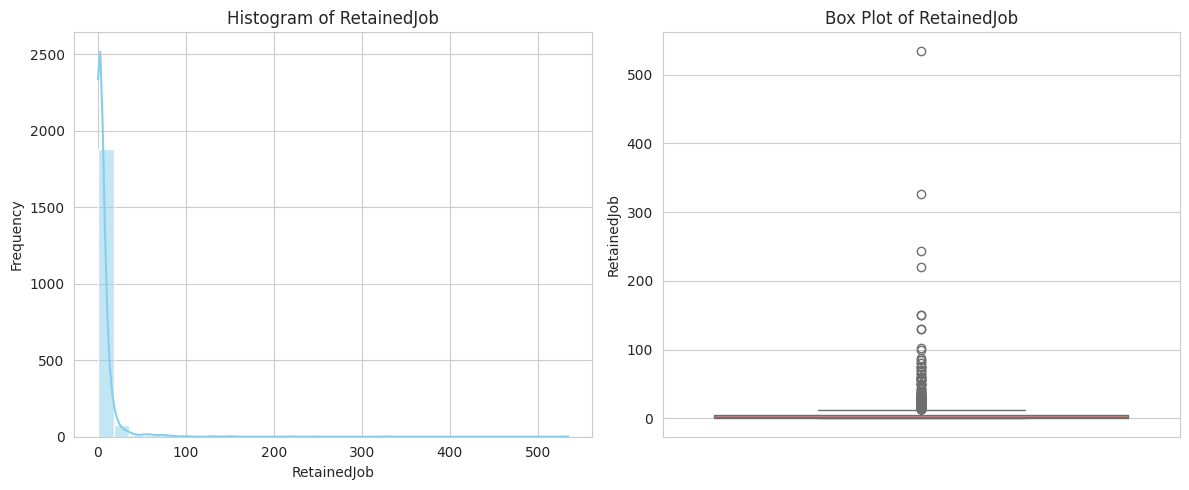

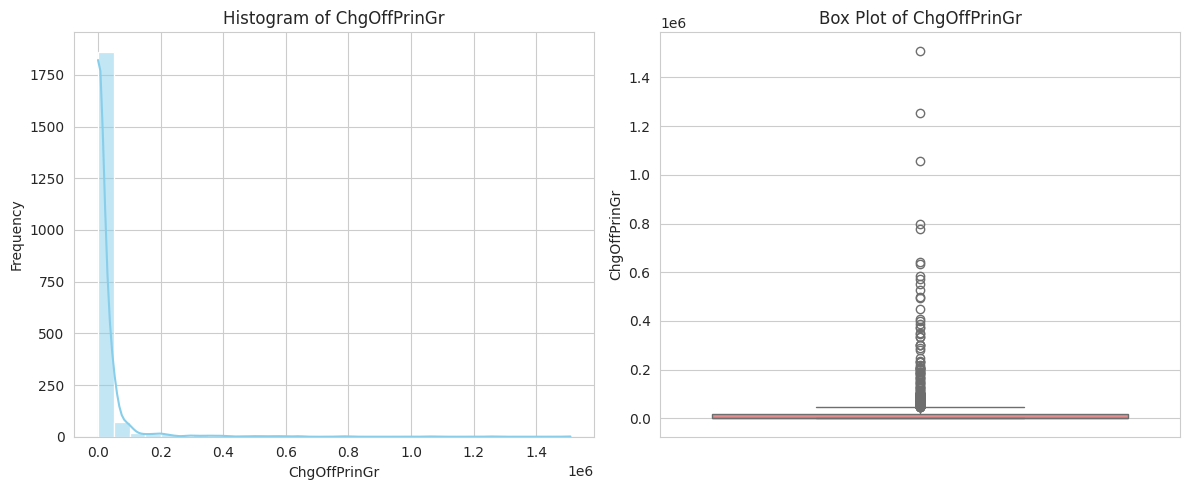

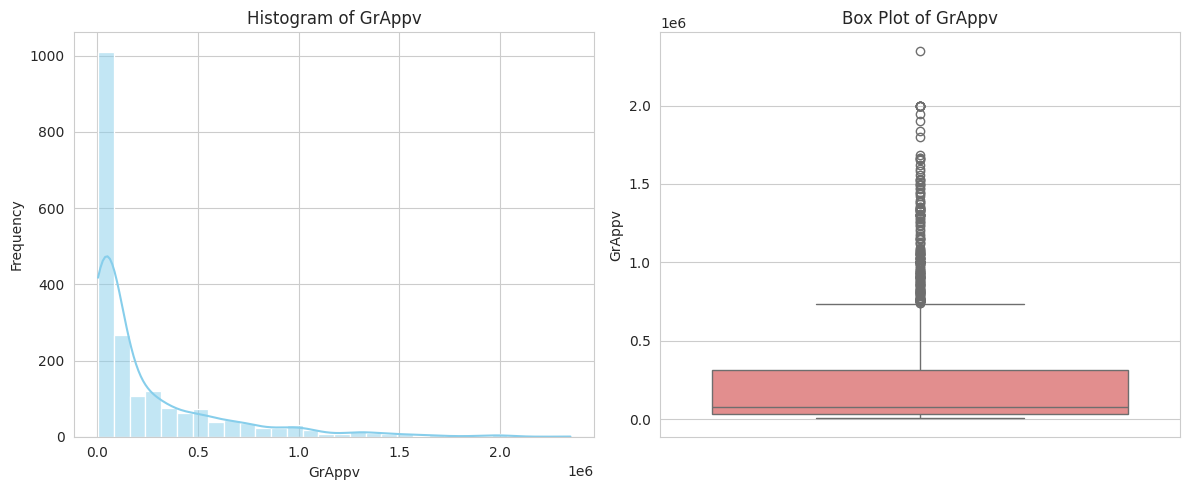

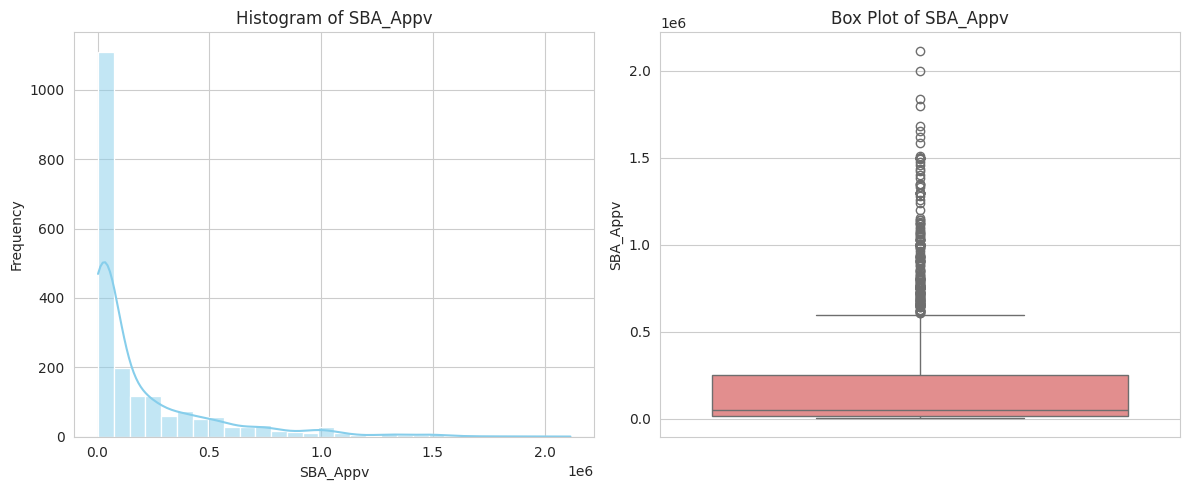

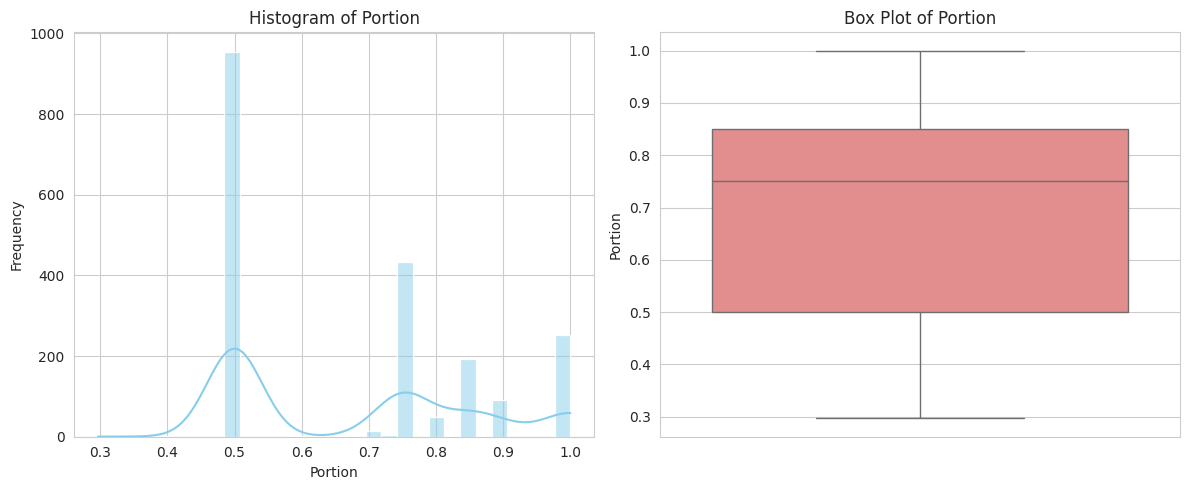

Generating plots for categorical/binary columns...


/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


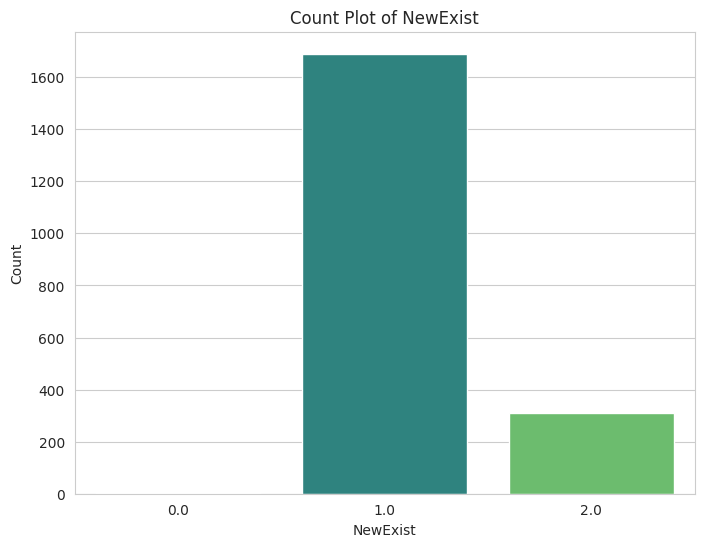

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


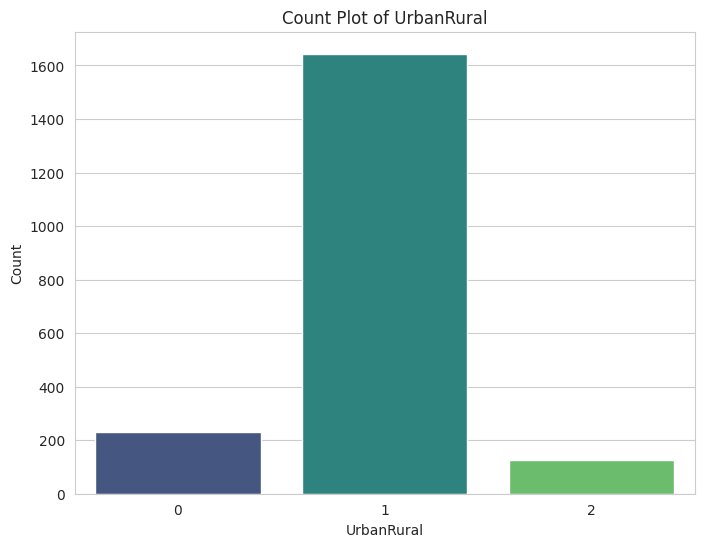

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


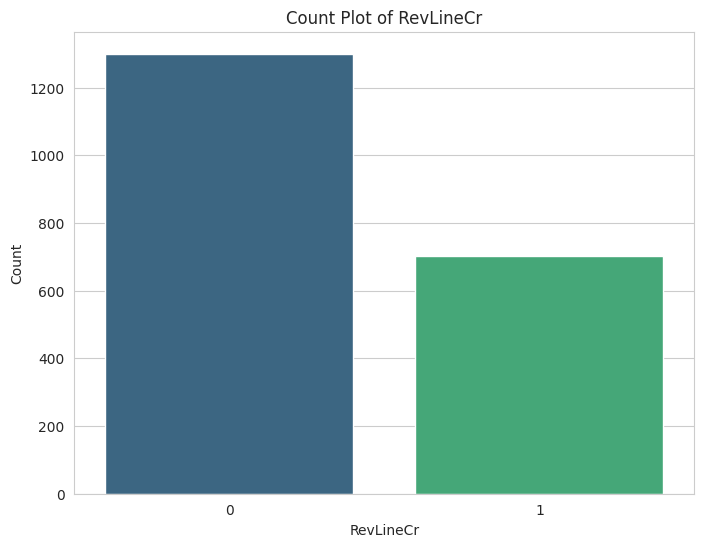

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


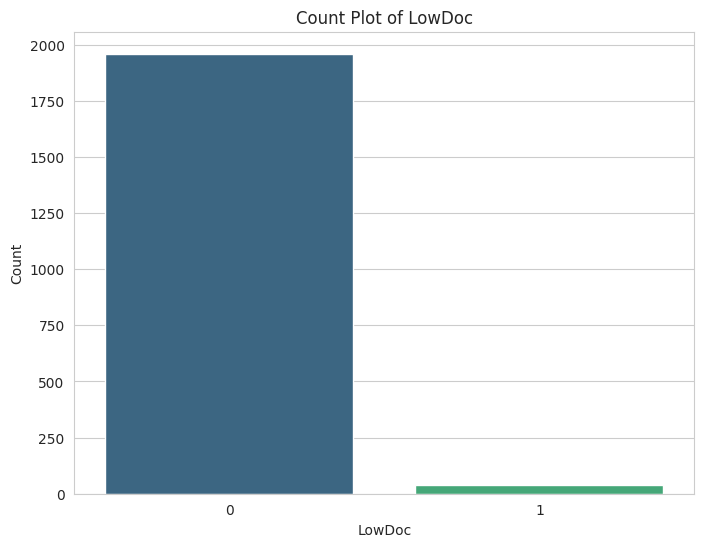

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


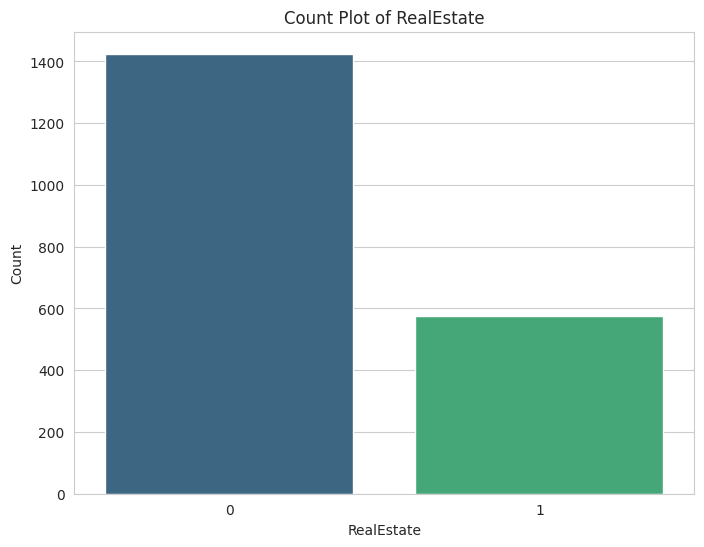

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


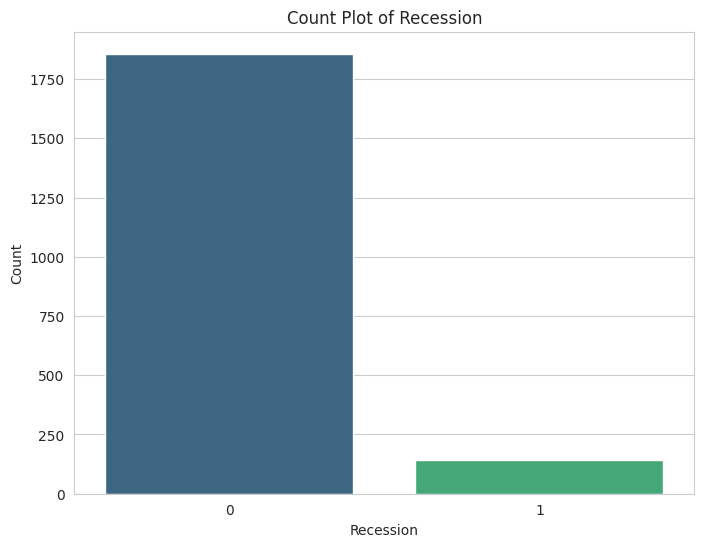

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


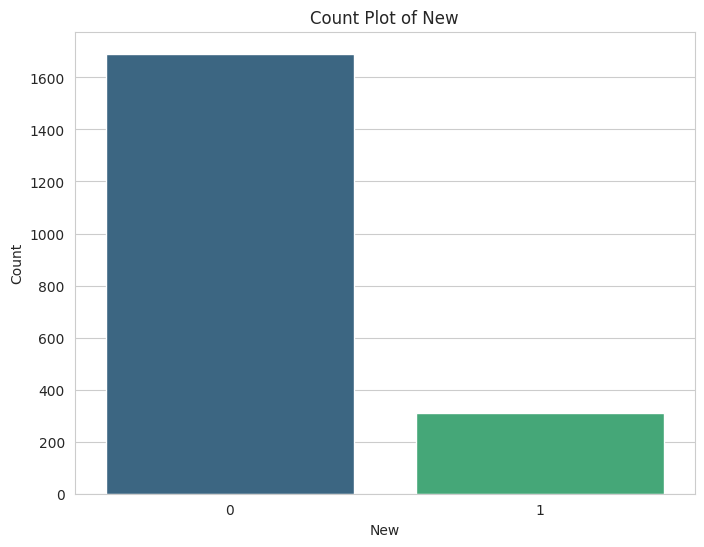

/tmp/ipykernel_4596/849262983.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


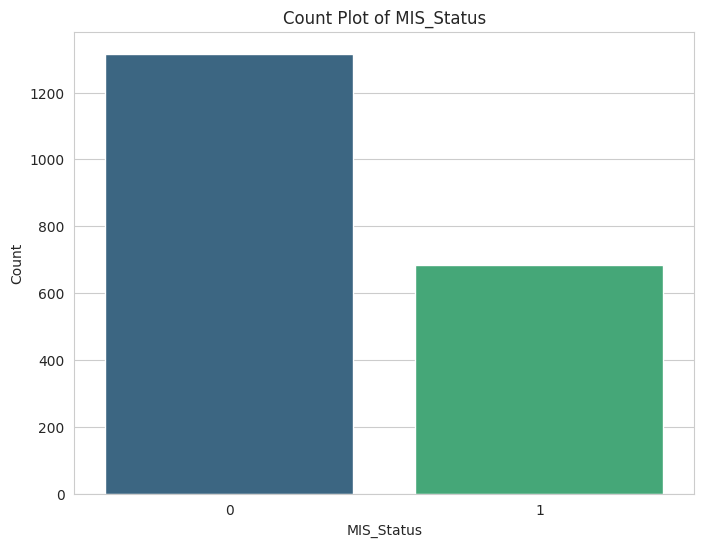

Univariate analysis complete.


In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Define columns based on their nature
continuous_numerical_cols = [
    'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'ChgOffPrinGr', 'GrAppv', 'SBA_Appv', 'Portion'
]
categorical_binary_cols = [
    'NewExist', 'UrbanRural', 'RevLineCr', 'LowDoc', 'RealEstate', 'Recession', 'New', 'MIS_Status'
]

print("Generating plots for continuous numerical columns...")
for col in continuous_numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box plot
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

print("Generating plots for categorical/binary columns...")
for col in categorical_binary_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

print("Univariate analysis complete.")

Correlation matrix

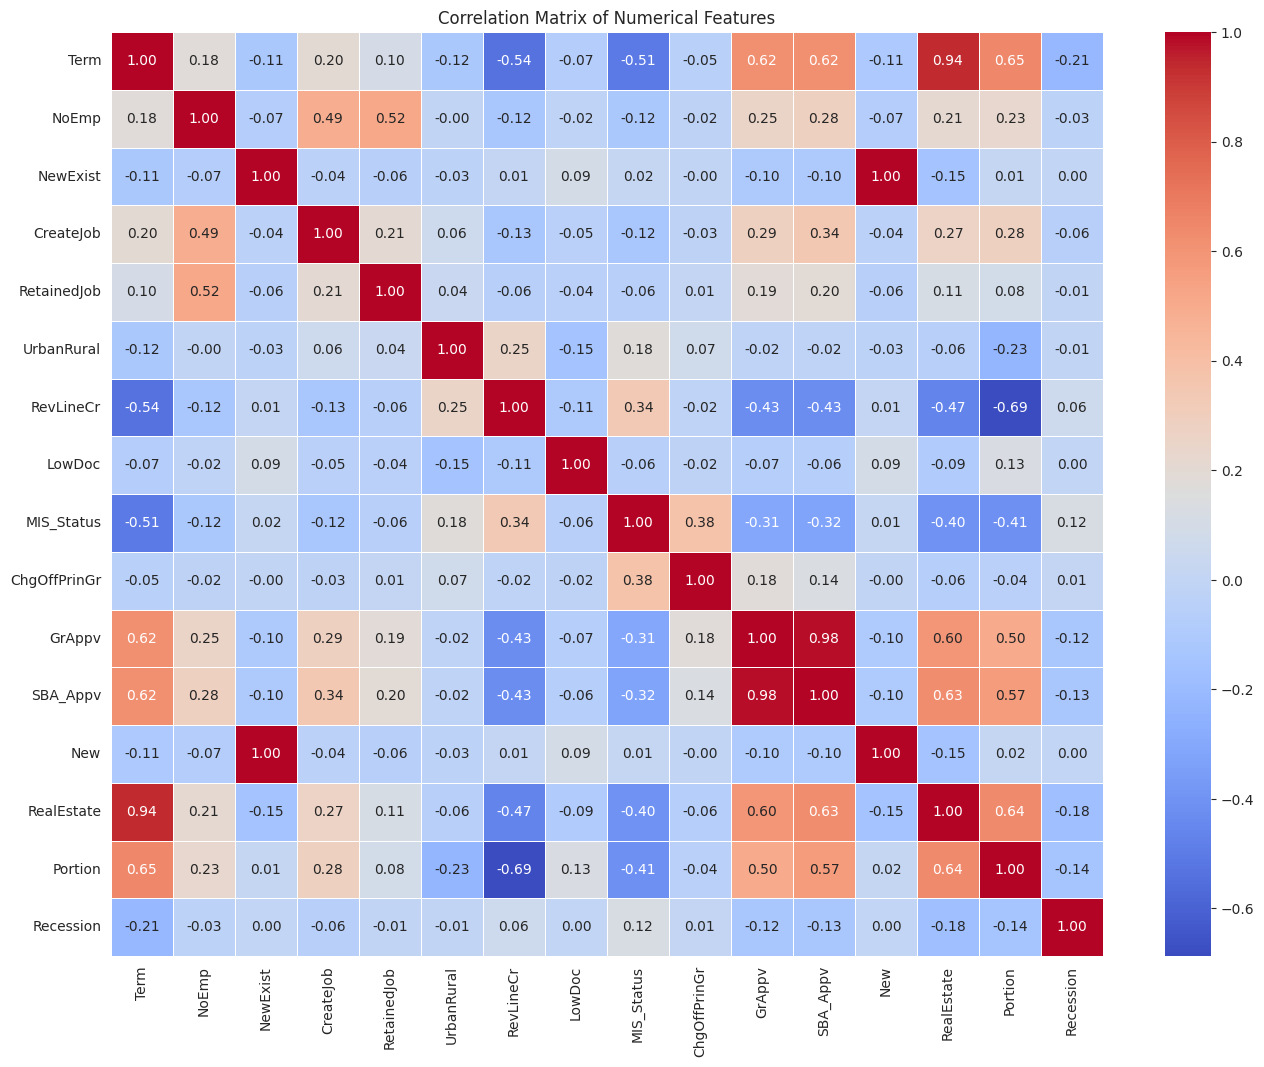

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Bivariate Analysis

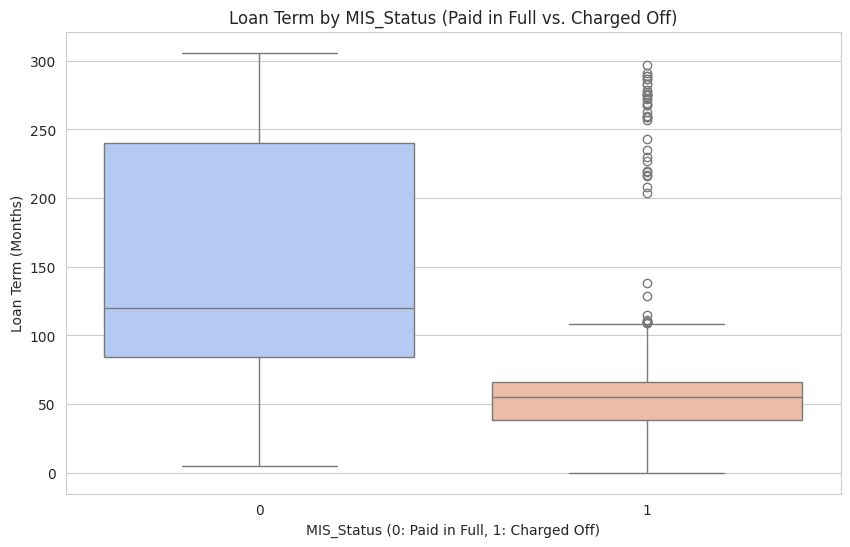

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: MIS_Status vs. Term
plt.figure(figsize=(10, 6))
sns.boxplot(x='MIS_Status', y='Term', data=df, palette='coolwarm', hue='MIS_Status', legend=False)
plt.title('Loan Term by MIS_Status (Paid in Full vs. Charged Off)')
plt.xlabel('MIS_Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('Loan Term (Months)')
plt.show()

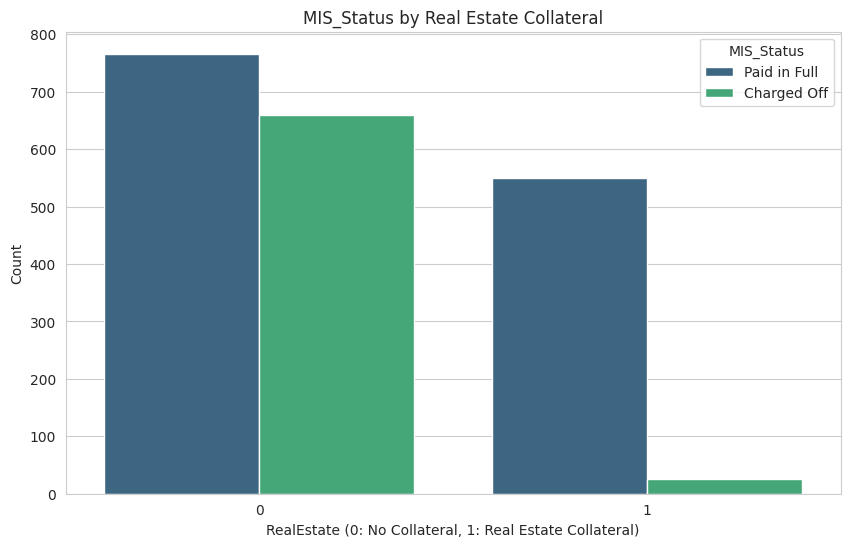

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: MIS_Status vs. RealEstate
plt.figure(figsize=(10, 6))
sns.countplot(x='RealEstate', hue='MIS_Status', data=df, palette='viridis')
plt.title('MIS_Status by Real Estate Collateral')
plt.xlabel('RealEstate (0: No Collateral, 1: Real Estate Collateral)')
plt.ylabel('Count')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

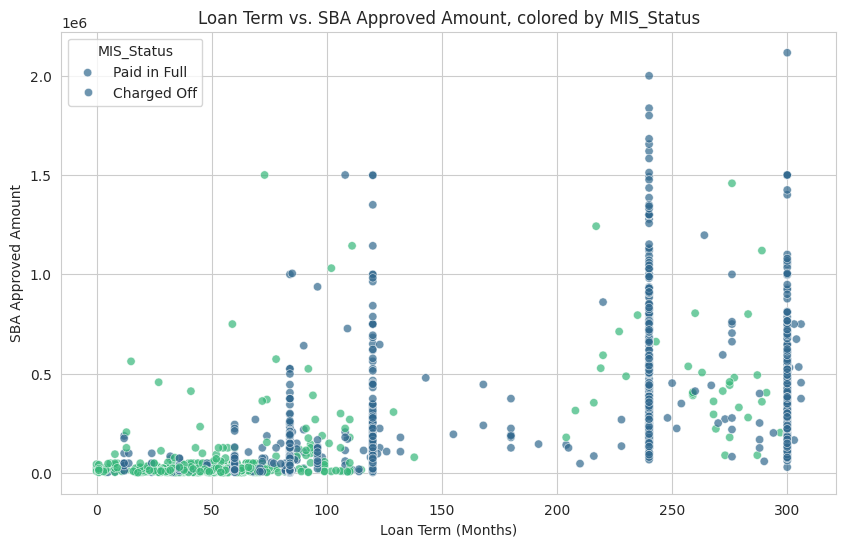

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: Term vs. SBA_Appv
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Term', y='SBA_Appv', data=df, hue='MIS_Status', palette='viridis', alpha=0.7)
plt.title('Loan Term vs. SBA Approved Amount, colored by MIS_Status')
plt.xlabel('Loan Term (Months)')
plt.ylabel('SBA Approved Amount')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

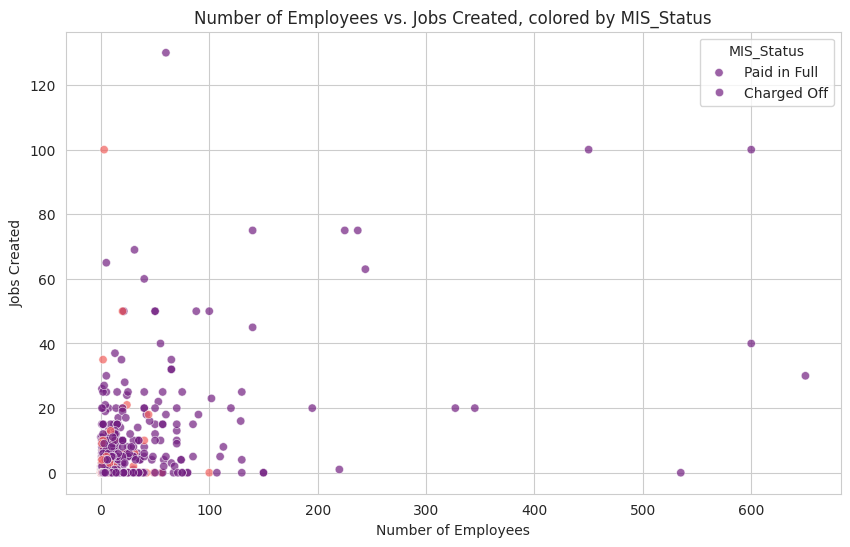

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: NoEmp vs. CreateJob
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NoEmp', y='CreateJob', data=df, hue='MIS_Status', palette='magma', alpha=0.7)
plt.title('Number of Employees vs. Jobs Created, colored by MIS_Status')
plt.xlabel('Number of Employees')
plt.ylabel('Jobs Created')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

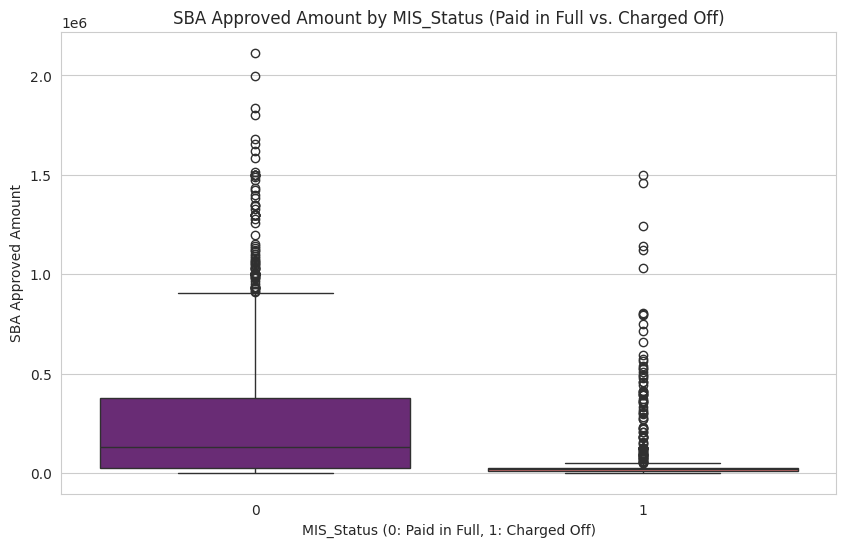

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: MIS_Status vs. SBA_Appv
plt.figure(figsize=(10, 6))
sns.boxplot(x='MIS_Status', y='SBA_Appv', data=df, palette='magma', hue='MIS_Status', legend=False)
plt.title('SBA Approved Amount by MIS_Status (Paid in Full vs. Charged Off)')
plt.xlabel('MIS_Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('SBA Approved Amount')
plt.show()

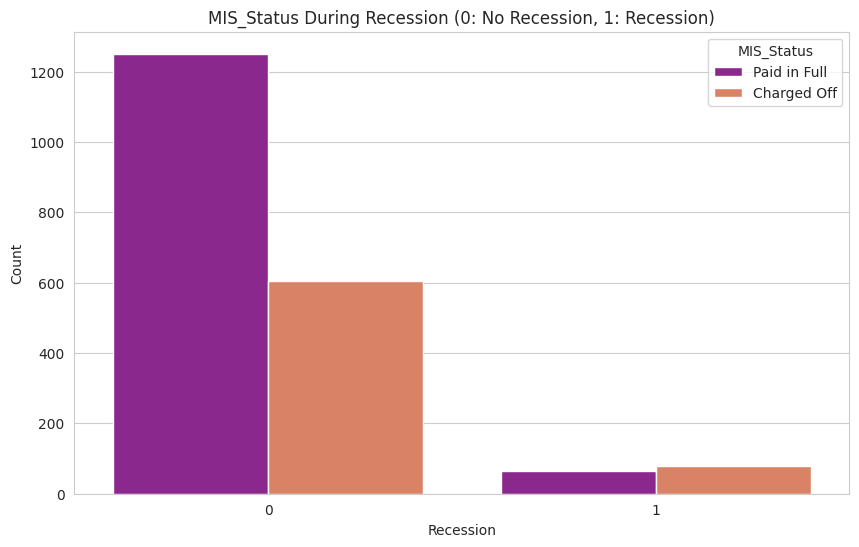

Bivariate analysis plots generated for key features.


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: MIS_Status vs. Recession
plt.figure(figsize=(10, 6))
sns.countplot(x='Recession', hue='MIS_Status', data=df, palette='plasma')
plt.title('MIS_Status During Recession (0: No Recession, 1: Recession)')
plt.xlabel('Recession')
plt.ylabel('Count')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

print("Bivariate analysis plots generated for key features.")

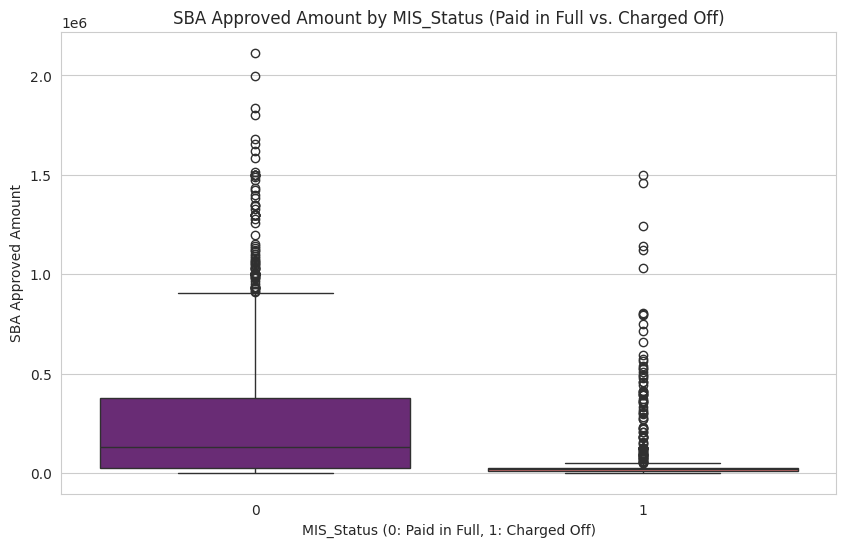

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Bivariate Analysis: MIS_Status vs. SBA_Appv
plt.figure(figsize=(10, 6))
sns.boxplot(x='MIS_Status', y='SBA_Appv', data=df, palette='magma', hue='MIS_Status', legend=False)
plt.title('SBA Approved Amount by MIS_Status (Paid in Full vs. Charged Off)')
plt.xlabel('MIS_Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('SBA Approved Amount')
plt.show()

## Multivariate Analysis


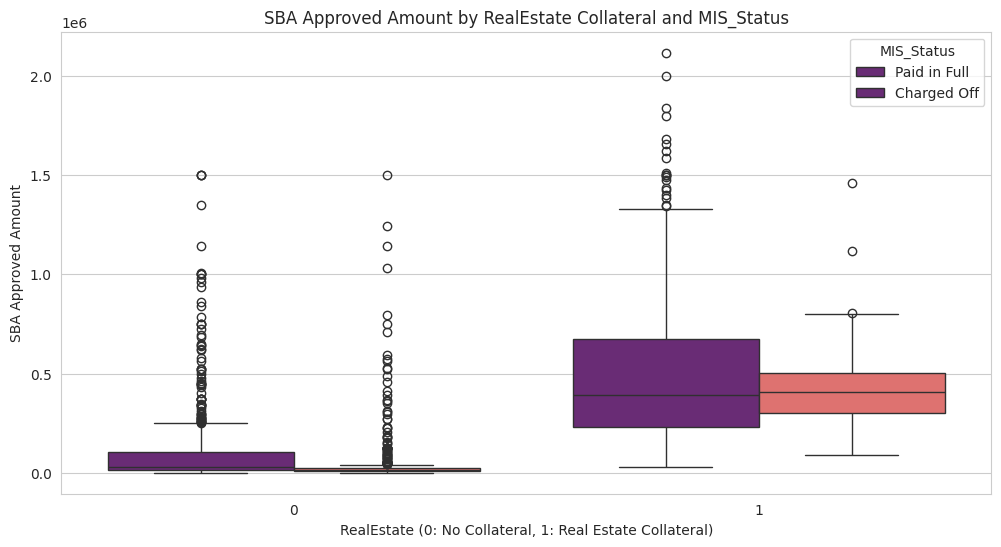

Multivariate plot for SBA_Appv, RealEstate, and MIS_Status generated.


In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# 2. Interaction between SBA_Appv, RealEstate, and MIS_Status
plt.figure(figsize=(12, 6))
sns.boxplot(x='RealEstate', y='SBA_Appv', hue='MIS_Status', data=df, palette='magma')
plt.title('SBA Approved Amount by RealEstate Collateral and MIS_Status')
plt.xlabel('RealEstate (0: No Collateral, 1: Real Estate Collateral)')
plt.ylabel('SBA Approved Amount')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

print("Multivariate plot for SBA_Appv, RealEstate, and MIS_Status generated.")

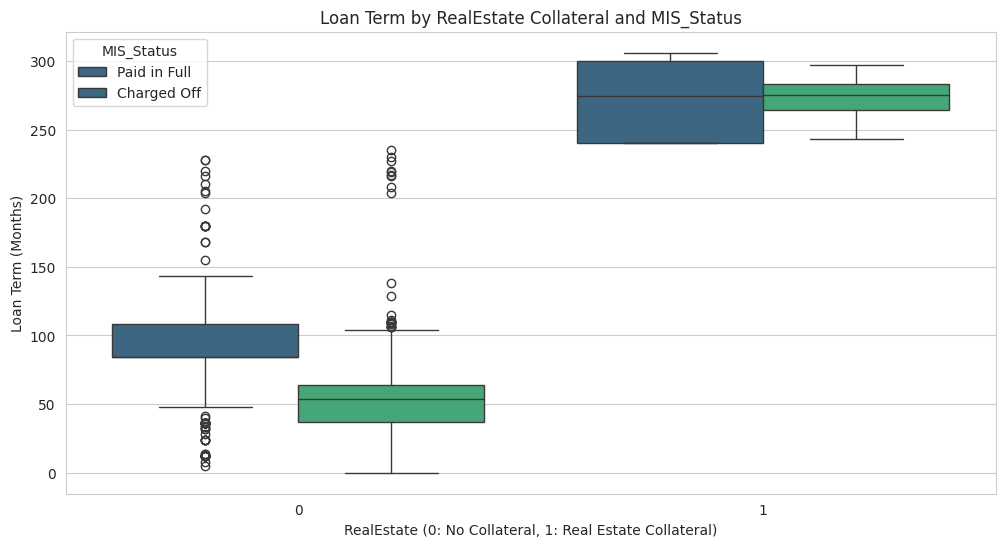

Multivariate plot for Term, RealEstate, and MIS_Status generated.


In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# 1. Interaction between Term, RealEstate, and MIS_Status
plt.figure(figsize=(12, 6))
sns.boxplot(x='RealEstate', y='Term', hue='MIS_Status', data=df, palette='viridis')
plt.title('Loan Term by RealEstate Collateral and MIS_Status')
plt.xlabel('RealEstate (0: No Collateral, 1: Real Estate Collateral)')
plt.ylabel('Loan Term (Months)')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

print("Multivariate plot for Term, RealEstate, and MIS_Status generated.")

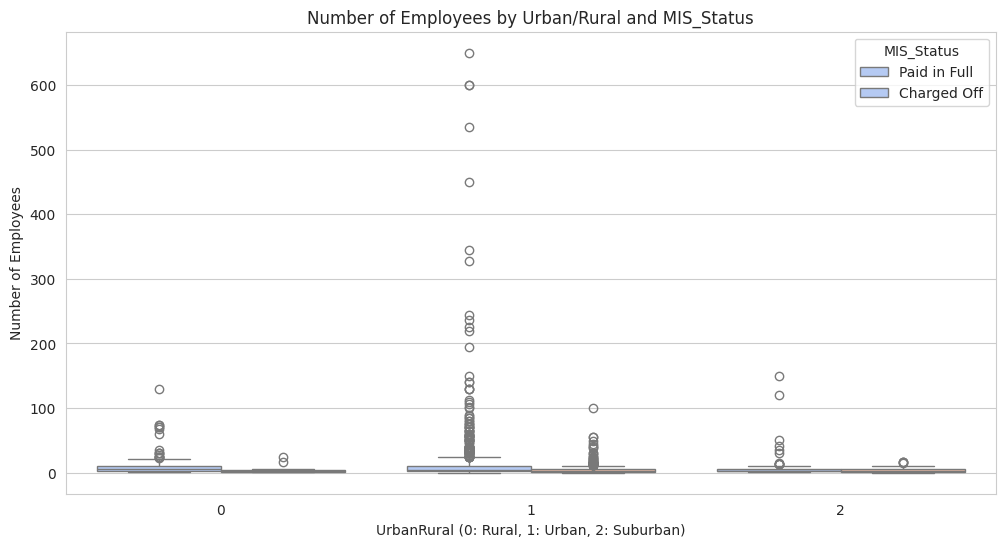

Multivariate plot for NoEmp, UrbanRural, and MIS_Status generated.


In [137]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# 3. Interaction between NoEmp, UrbanRural, and MIS_Status
plt.figure(figsize=(12, 6))
sns.boxplot(x='UrbanRural', y='NoEmp', hue='MIS_Status', data=df, palette='coolwarm')
plt.title('Number of Employees by Urban/Rural and MIS_Status')
plt.xlabel('UrbanRural (0: Rural, 1: Urban, 2: Suburban)')
plt.ylabel('Number of Employees')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.show()

print("Multivariate plot for NoEmp, UrbanRural, and MIS_Status generated.")

##Fit  the machine learning model

prediction Variable is Mis_status which is basically default status - Paid in Full (1) not defaulted and chargedoff(0) is defaulted.

Performing Train-Test split

In [138]:
print(X_test)

      Term  NoEmp  NewExist  CreateJob  RetainedJob  UrbanRural  RevLineCr  \
1283   300      2       1.0          0            2           1          0   
1759     1      6       1.0          0            6           2          0   
1963    84      6       1.0          0            6           1          1   
1075   300      9       1.0          0            9           1          0   
2100   120      3       1.0          0            0           0          0   
...    ...    ...       ...        ...          ...         ...        ...   
1516    55      1       1.0          0            1           1          1   
769    120      2       2.0          0            2           1          0   
1875    82      9       1.0          1           10           1          1   
42      56      3       1.0          0            0           1          1   
1618   300      1       1.0          2            1           1          0   

      LowDoc  SBA_Appv  RealEstate  Portion  Recession  
1283  

In [139]:
print(X_train)

      Term  NoEmp  NewExist  CreateJob  RetainedJob  UrbanRural  RevLineCr  \
294     90      2       1.0          1            1           1          0   
728     78      3       1.0          0            3           1          1   
1956   240     50       1.0         20            0           2          0   
2066    84      1       2.0          0            1           1          0   
1019   120     24       1.0         24           24           1          0   
...    ...    ...       ...        ...          ...         ...        ...   
467     69      2       1.0          0            2           1          1   
1459   240      5       1.0         25            5           1          0   
1369   276      4       1.0          4            4           1          0   
1524   120     10       1.0          0           10           1          0   
1037   240      2       1.0          6            6           1          0   

      LowDoc  SBA_Appv  RealEstate  Portion  Recession  
294   

In [140]:
print(y_test)

1283    0
1759    1
1963    0
1075    0
2100    0
       ..
1516    1
769     0
1875    0
42      1
1618    0
Name: MIS_Status, Length: 601, dtype: int64


In [141]:
print(y_train)

294     0
728     1
1956    0
2066    0
1019    0
       ..
467     1
1459    0
1369    0
1524    0
1037    0
Name: MIS_Status, Length: 1400, dtype: int64


Performing Logistic Regression

In [142]:

import statsmodels.api as sm

# Add a constant (intercept) to the features for statsmodels
X_train_sm = sm.add_constant(X_train)

# Initialize and fit the Logistic Regression model
lr_model1 = sm.Logit(y_train, X_train_sm).fit()

print(lr_model1.summary())


Optimization terminated successfully.
         Current function value: 0.429996
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1387
Method:                           MLE   Df Model:                           12
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3307
Time:                        11:44:32   Log-Likelihood:                -601.99
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                1.327e-119
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2881      0.580      3.948      0.000       1.152       3.424
Term           -0.0438    

Removing the 'NewExist' column and re-running the logistic regression:

In [143]:
x_train_2 = X_train_sm.drop('NewExist', axis=1)
x_train2 = sm.add_constant(x_train_2)

lr_model2 = sm.Logit(y_train, x_train2).fit()
print(lr_model2.summary())

Optimization terminated successfully.
         Current function value: 0.430026
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1388
Method:                           MLE   Df Model:                           11
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3306
Time:                        11:44:32   Log-Likelihood:                -602.04
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                1.834e-120
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3391      0.552      4.239      0.000       1.257       3.421
Term           -0.0437    

Removing the 'Portion' column and re-running the logistic regression:

In [144]:
x_train_3 = x_train_2.drop('Portion', axis=1)
x_train3 = sm.add_constant(x_train_3)

lr_model3 = sm.Logit(y_train, x_train3).fit()
print(lr_model3.summary())

Optimization terminated successfully.
         Current function value: 0.430076
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1389
Method:                           MLE   Df Model:                           10
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3306
Time:                        11:44:32   Log-Likelihood:                -602.11
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                2.481e-121
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.5043      0.332      7.536      0.000       1.853       3.156
Term           -0.0435    

Removing the 'RevLineCr' column and re-running the logistic regression:

In [145]:
x_train_4 = x_train_3.drop('RevLineCr', axis=1)
x_train4 = sm.add_constant(x_train_4)

lr_model4 = sm.Logit(y_train, x_train4).fit()
print(lr_model4.summary())

Optimization terminated successfully.
         Current function value: 0.430432
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1390
Method:                           MLE   Df Model:                            9
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3300
Time:                        11:44:32   Log-Likelihood:                -602.61
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                4.853e-122
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3909      0.311      7.680      0.000       1.781       3.001
Term           -0.0428    

Removing the 'SBA_Appv' column and re-running the logistic regression:

In [146]:
x_train_5 = x_train_4.drop('SBA_Appv', axis=1)
x_train5 = sm.add_constant(x_train_5)

lr_model5 = sm.Logit(y_train, x_train5).fit()
print(lr_model5.summary())

Optimization terminated successfully.
         Current function value: 0.431386
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1391
Method:                           MLE   Df Model:                            8
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3285
Time:                        11:44:32   Log-Likelihood:                -603.94
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                2.045e-122
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3491      0.309      7.611      0.000       1.744       2.954
Term           -0.0418    

Removing the 'Recession' column and re-running the logistic regression:

In [147]:
x_train_6 = x_train_5.drop('Recession', axis=1)
x_train6 = sm.add_constant(x_train_6)

lr_model6 = sm.Logit(y_train, x_train6).fit()
print(lr_model6.summary())

Optimization terminated successfully.
         Current function value: 0.432360
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1392
Method:                           MLE   Df Model:                            7
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3270
Time:                        11:44:32   Log-Likelihood:                -605.30
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                8.287e-123
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2374      0.299      7.479      0.000       1.651       2.824
Term           -0.0407    

Removing CreateJob and re running logistic regression

In [148]:
x_train_7 = x_train_6.drop('CreateJob', axis=1)
x_train7 = sm.add_constant(x_train_7)

lr_model7 = sm.Logit(y_train, x_train7).fit()
print(lr_model7.summary())

Optimization terminated successfully.
         Current function value: 0.434015
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1393
Method:                           MLE   Df Model:                            6
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3244
Time:                        11:44:32   Log-Likelihood:                -607.62
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                7.999e-123
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2275      0.299      7.439      0.000       1.641       2.814
Term           -0.0407    

Removing RetainedJob column and re running regression

In [149]:
x_train_8 = x_train_7.drop('RetainedJob', axis=1)
x_train8 = sm.add_constant(x_train_8)

lr_model8 = sm.Logit(y_train, x_train8).fit()
print(lr_model8.summary())

Optimization terminated successfully.
         Current function value: 0.435298
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             MIS_Status   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1394
Method:                           MLE   Df Model:                            5
Date:                Thu, 16 Apr 2026   Pseudo R-squ.:                  0.3224
Time:                        11:44:32   Log-Likelihood:                -609.42
converged:                       True   LL-Null:                       -899.43
Covariance Type:            nonrobust   LLR p-value:                4.203e-123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2007      0.298      7.391      0.000       1.617       2.784
Term          -0.0409      0.

### 1. The Regression Equation
Based on the coefficients, the model for the probability ($p$) of default is:

$$\ln\left(\frac{p}{1-p}\right) = 2.20 - 0.04(\text{Term}) - 0.01(\text{NoEmp}) + 0.60(\text{UrbanRural}) - 1.25(\text{LowDoc}) + 4.97(\text{RealEstate})$$
2. My inferences from predicted model is
* **Term & Employment:** Longer loan terms and more employees significantly **lower** the risk of default.
* **Program & Location:** Using the **LowDoc** program reduces risk, while **Urban** loans show a higher tendency to default.
* **Real Estate:** This is the most influential predictor in the model, acting as the primary driver for determining the final loan status.
* **Model Strength:** A **Pseudo R-squared of 0.32** indicates a strong fit for a logistic model, successfully identifying the key triggers for loan failure.

## Model Diagnostics

Confusion Matrix:


array([[361,  34],
       [ 44, 162]])

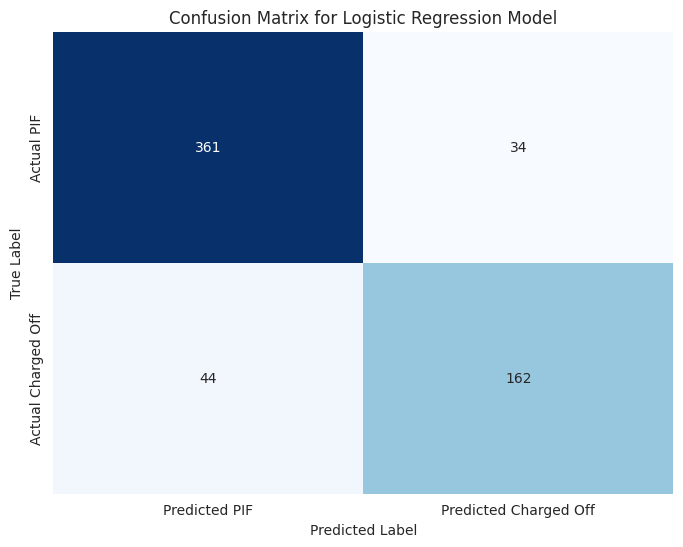

In [150]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare X_test with the same columns as the final trained model (lr_model8)
# Ensure 'const' is added to X_test for statsmodels prediction
x_test_final = sm.add_constant(X_test[x_train8.drop('const', axis=1).columns])

# Get predicted classes (0 or 1) using a threshold of 0.5
y_pred = (lr_model8.predict(x_test_final) >= 0.5).astype(int)

# Calculate the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
display(conf_matrix)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted PIF', 'Predicted Charged Off'],
            yticklabels=['Actual PIF', 'Actual Charged Off'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

 The model correctly predicted 523 out of 601 cases. It is particularly strong at identifying "Paid in Full" (PIF) loans, with 361 correct predictions and only 34 misses.



AUC Score: 0.8808


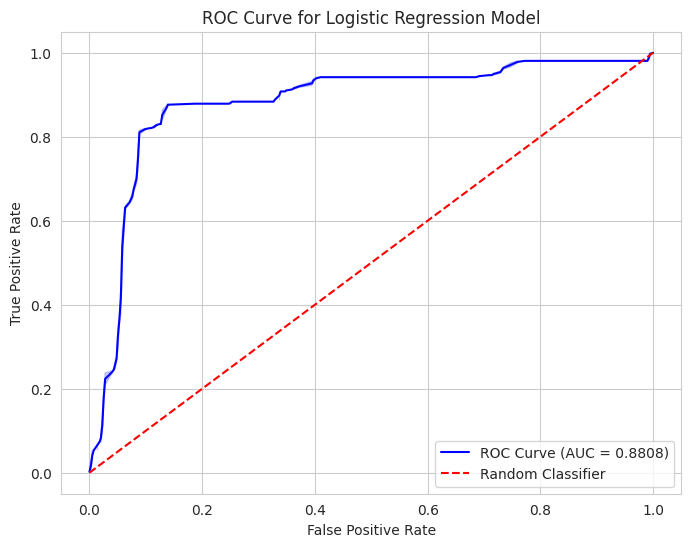

In [151]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# We need to make sure to add the constant to X_test for prediction using the statsmodels model

# Prepare X_test with the same columns as the final trained model (lr_model8)
x_test8 = sm.add_constant(X_test[x_train8.drop('const', axis=1).columns])

# Predict probabilities
y_pred_proba_sm_final_model = lr_model8.predict(x_test8)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba_sm_final_model)
print(f'AUC Score: {auc_score:.4f}')

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_sm_final_model)

# Plot ROC curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr, y=tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
sns.lineplot(x=[0, 1], y=[0, 1], linestyle='--', color='red', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

An AUC score of 0.8808  indicates that there is an 88% probability that the model will correctly rank a randomly chosen defaulted loan higher than a randomly chosen healthy loan.